==================================================
                 TASK SUBMISSION
==================================================

Full Name:         Pranav Rase
Internship Track:  Data Analytics
Task Title:        Task 1 - EDA on Retail Sales Data

==================================================

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [17]:
# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="ISO-8859-1")

print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- COLUMN DATA TYPES ---")
print(df.dtypes)

print("\n--- NULL VALUE CHECK ---")
print(df.isnull().sum())

# Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

--- DATASET SHAPE ---
Rows: 9994, Columns: 21

--- COLUMN DATA TYPES ---
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

--- NULL VALUE CHECK ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
D

In [18]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print("--- NUMERICAL DESCRIPTIVE STATISTICS ---")
stats_df = df[num_cols].describe().T
stats_df['mode'] = df[num_cols].mode().iloc[0]
print(stats_df[['count', 'mean', 'std', 'min', '50%', 'max', 'mode']].rename(columns={'50%': 'median'}))

--- NUMERICAL DESCRIPTIVE STATISTICS ---
           count        mean         std       min   median        max   mode
Sales     9994.0  229.858001  623.245101     0.444  54.4900  22638.480  12.96
Quantity  9994.0    3.789574    2.225110     1.000   3.0000     14.000   3.00
Discount  9994.0    0.156203    0.206452     0.000   0.2000      0.800   0.00
Profit    9994.0   28.656896  234.260108 -6599.978   8.6665   8399.976   0.00


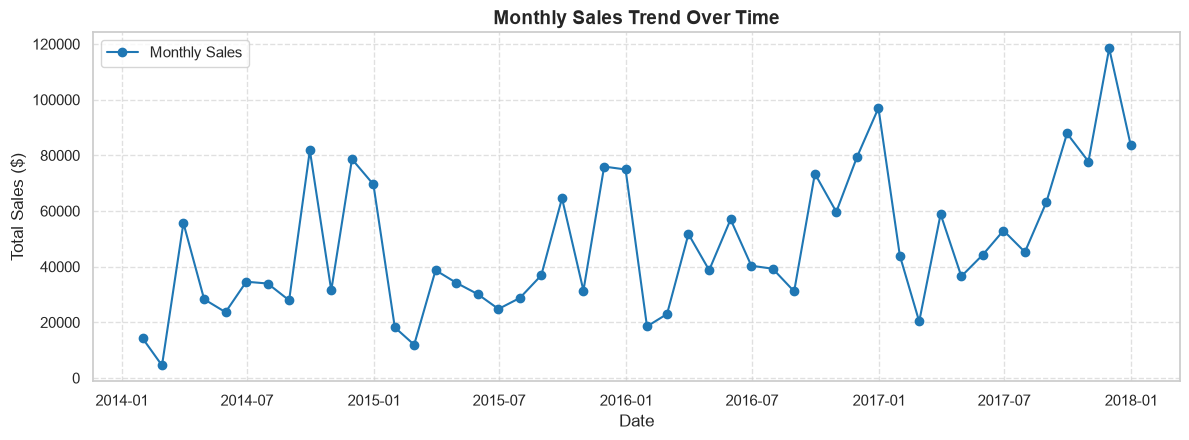

In [19]:
# Resample by month (compatible with older & newer pandas versions)
df_time = df.set_index('Order Date')
try:
    monthly_sales = df_time['Sales'].resample('ME').sum()
except ValueError:
    monthly_sales = df_time['Sales'].resample('M').sum()

plt.figure(figsize=(12, 4.5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#1f77b4', label='Monthly Sales')
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

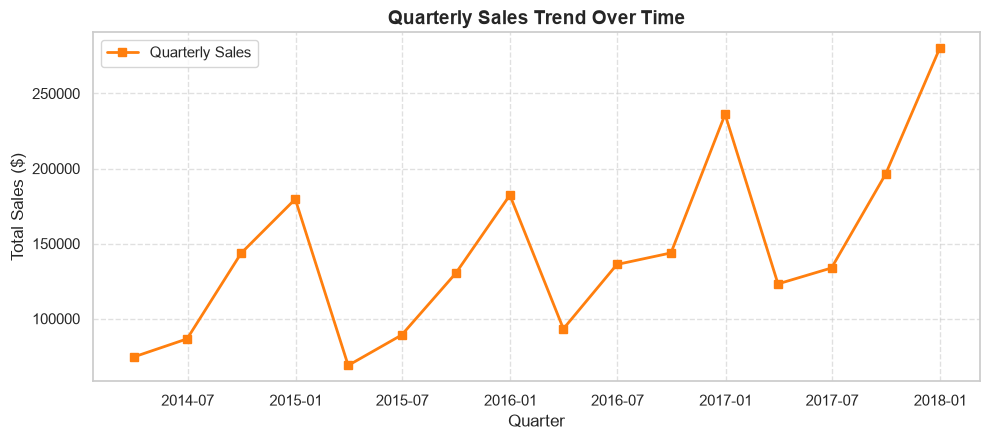

In [20]:
# Resample by quarter
try:
    quarterly_sales = df_time['Sales'].resample('QE').sum()
except ValueError:
    quarterly_sales = df_time['Sales'].resample('Q').sum()

plt.figure(figsize=(10, 4.5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='s', color='#ff7f0e', linewidth=2, label='Quarterly Sales')
plt.title('Quarterly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

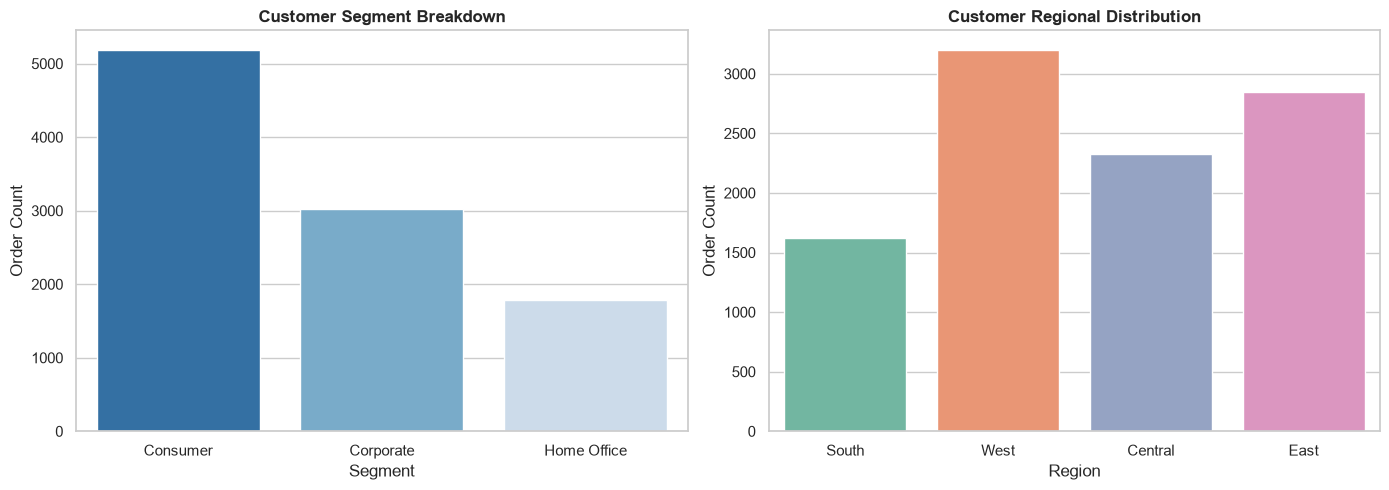

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution
sns.countplot(data=df, x='Segment', hue='Segment', legend=False, palette='Blues_r', ax=axes[0])
axes[0].set_title('Customer Segment Breakdown', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Order Count')

# Regional distribution
sns.countplot(data=df, x='Region', hue='Region', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Customer Regional Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

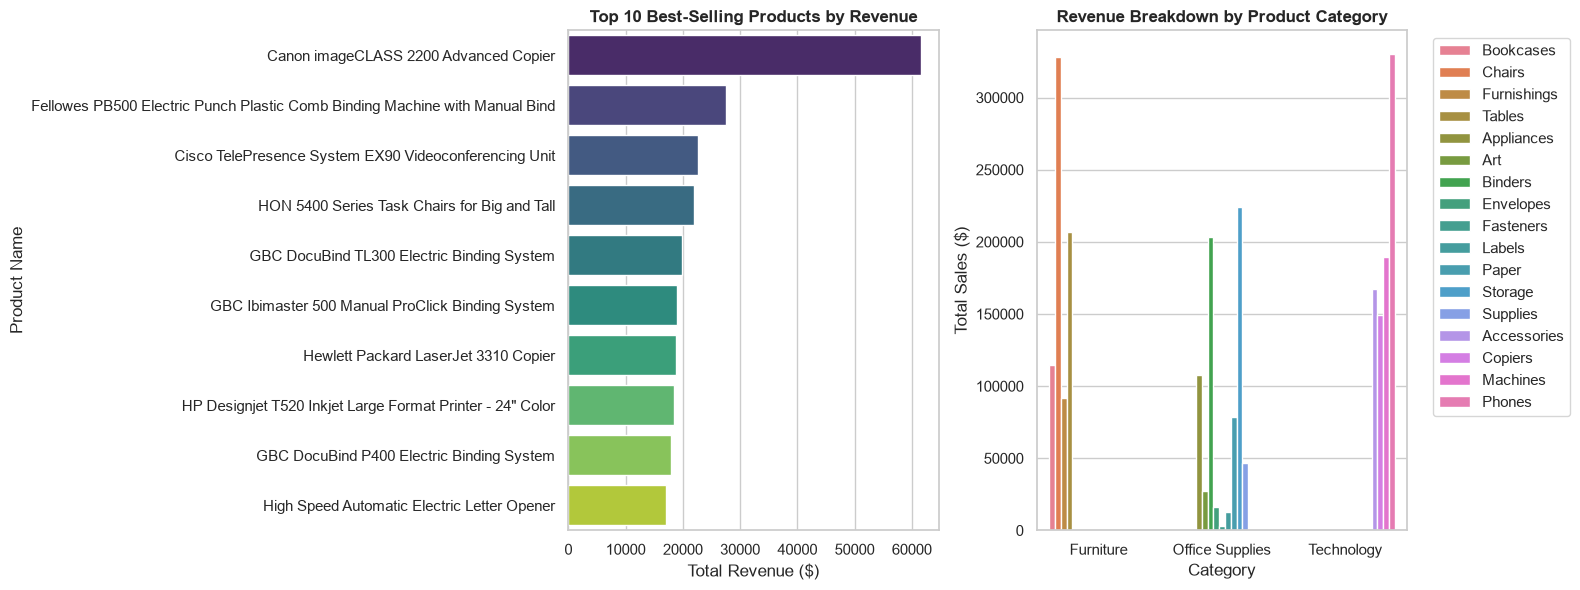

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Best-Selling Products
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_products, 
    y='Product Name', 
    x='Sales', 
    hue='Product Name', # Assigned hue to fix warning
    legend=False,       # Turned off redundant legend
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Top 10 Best-Selling Products by Revenue', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')

# Revenue by Category
cat_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()
sns.barplot(data=cat_sales, x='Category', y='Sales', hue='Sub-Category', ax=axes[1])
axes[1].set_title('Revenue Breakdown by Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

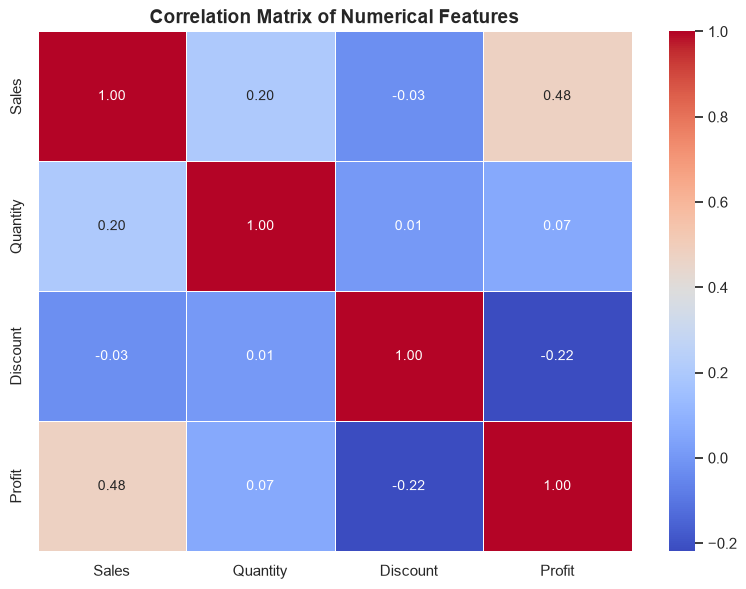

In [23]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

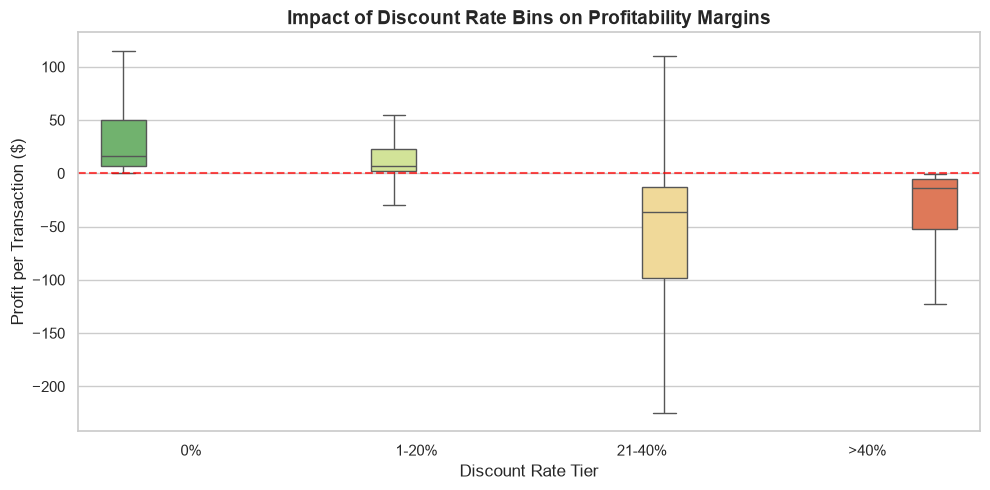

In [24]:
df['Discount_Bin'] = pd.cut(df['Discount'], bins=[-0.01, 0.0, 0.2, 0.4, 0.8], labels=['0%', '1-20%', '21-40%', '>40%'])

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    x='Discount_Bin', 
    y='Profit', 
    hue='Discount_Bin',  # Assigned hue to fix the warning
    legend=False,        # Turned off redundant legend
    showfliers=False, 
    palette='RdYlGn_r'
)
plt.title('Impact of Discount Rate Bins on Profitability Margins', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate Tier')
plt.ylabel('Profit per Transaction ($)')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
print("================================================================================")
print("                           CONCLUSION & RECOMMENDATIONS                         ")
print("================================================================================")
print("1. REVISE DISCOUNT STRATEGY:")
print("   - Cap maximum allowable promotional discounts at 20%. Discounts exceeding 20% consistently")
print("     yield negative profit margins despite boosting order volume.\n")
print("2. CAPITALIZE ON Q4 SEASONALITY:")
print("   - Increase inventory and targeted promotional campaigns starting in late September to prepare")
print("     for the Q4 demand spike (October–December).\n")
print("3. TARGETED B2B ACQUISITION IN CORPORATE/HOME OFFICE SEGMENTS:")
print("   - Consumer segment yields high order volume, but Corporate and Home Office customer segments")
print("     produce higher average order values. Introduce bulk-purchase loyalty incentives tailored for business clients.")
print("================================================================================")

                           CONCLUSION & RECOMMENDATIONS                         
1. REVISE DISCOUNT STRATEGY:
   - Cap maximum allowable promotional discounts at 20%. Discounts exceeding 20% consistently
     yield negative profit margins despite boosting order volume.

2. CAPITALIZE ON Q4 SEASONALITY:
   - Increase inventory and targeted promotional campaigns starting in late September to prepare
     for the Q4 demand spike (October–December).

3. TARGETED B2B ACQUISITION IN CORPORATE/HOME OFFICE SEGMENTS:
   - Consumer segment yields high order volume, but Corporate and Home Office customer segments
     produce higher average order values. Introduce bulk-purchase loyalty incentives tailored for business clients.
